# Phase 7 — Multiple Sequence Alignment & Conservation Analysis

Phase 6 produced the redundancy-reduced representative sets. This phase takes the
**98% set** (`orthologs_nr98.fasta`, chosen as the reference threshold that
retains species-level diversity), aligns it, and characterises the conservation
structure of the A29L protein family.

The sequences already carry `Genus|Accession|Species` headers curated in Phase 5,
so this phase makes **no network calls** — genus and species are read straight
from the headers.

The analysis proceeds in four parts:

1. **Align** with MAFFT L-INS-i, the accuracy-oriented mode suited to a set of
   this size.
2. **Pairwise identity** — an all-versus-all identity matrix over aligned
   positions.
3. **Genus heatmap** — the identity matrix ordered by genus, revealing within-
   and between-genus divergence.
4. **Conservation profiles** — per-column conservation across the alignment, and
   the same signal mapped onto the Monkeypox A29L reference with its known
   functional domains.

As in earlier phases, the alignment is checkpointed and skipped on re-run, all
parameters live in one `Config`, and progress is logged to `phase7.log`.

**Steps**

0. Setup & configuration
1. Align with MAFFT L-INS-i
2. Pairwise identity matrix
3. Genus-ordered identity heatmap
4. Conservation profiles (global and reference-mapped)

## Step 0 — Setup & configuration

All paths, the MAFFT command, the reference query sequence, the genus display
order, and the domain annotation live in one frozen `Config`. The reference is
matched by **sequence**, not by accession: the A29L query used throughout the
pipeline is stored in `reference_seq`, and Step 4 locates whichever aligned row
carries that exact sequence — robust to accession or header changes.

FASTA parsing reuses `seqio_utils`; MAFFT runs through the shared `run_command`
helper. The `gorder` list controls genus ordering in the heatmap; the `domains`
list defines the functional regions drawn on the reference-mapped profile. Both
are display choices, kept here so they can be seen and adjusted in one place.

In [1]:
from __future__ import annotations

import logging
import subprocess
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from seqio_utils import parse_fasta_records

In [2]:
@dataclass(frozen=True)
class Config:
    input_fasta: Path = Path("output_phase6/orthologs_nr98.fasta")

    wsl_prefix: list[str] = field(default_factory=lambda: ["wsl"])
    mafft_threads: int = 4

    figure_formats: tuple[str, ...] = ("png",)
    figure_dpi: int = 1000

    reference_seq: str = (
        "MDGTLFPGDDDLAIPATEFFSTKAAKNPETKREAIVKAYGDDNEETLKQRLTNLEKKITNITTKFEQIEK"
        "CCKHNDEVLFRLENHAETLRAAMISLAKKIDVQTGRRPYE"
    )

    gorder: tuple[str, ...] = (
        "Orthopoxvirus", "Centapoxvirus", "Capripoxvirus", "Cervidpoxvirus",
        "Suipoxvirus", "Yatapoxvirus", "Leporipoxvirus", "Parapoxvirus",
        "Vespertilionpoxvirus", "Crocodylidpoxvirus", "unclassified",
    )

    domains: tuple[tuple, ...] = (
        (1, 20, "#FF4C4C", "Signal Peptide"),
        (21, 32, "#4CAF50", "GAG-binding Domain"),
        (33, 42, "#A9A9A9", "Spacer"),
        (43, 84, "#5C5CE0", "Coiled-coil Domain"),
        (85, 110, "#1C1C84", "Leucine Zipper Domain"),
    )
    disulfide_span: tuple[int, int] = (71, 72)

    out_dir: Path = field(default_factory=lambda: Path("output_phase7"))

    @property
    def aligned_fasta(self) -> Path:
        return self.out_dir / "A29L_msa_linsi.fasta"

    @property
    def pairwise_csv(self) -> Path:
        return self.out_dir / "pairwise_identity.csv"

    @property
    def heatmap_stem(self) -> Path:
        return self.out_dir / "A29L_identity_heatmap"

    @property
    def global_profile_stem(self) -> Path:
        return self.out_dir / "A29L_global_conservation_profile"

    @property
    def reference_profile_stem(self) -> Path:
        return self.out_dir / "A29L_domain_conservation_profile"

    @property
    def reference_mapped_csv(self) -> Path:
        return self.out_dir / "A29L_reference_mapped_conservation.csv"


CFG = Config()
CFG.out_dir.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler(CFG.out_dir / "phase7.log"),
    ],
)
log = logging.getLogger("phase7")

if not CFG.input_fasta.exists():
    raise FileNotFoundError(f"{CFG.input_fasta} not found — run Phase 6 first.")

In [3]:
class CommandError(RuntimeError):
    """Raised when an external tool exits with a non-zero status."""


def run_command(cmd: list[str], stdout_path: Path, log_file: Path) -> None:
    log.info("Running: %s", " ".join(cmd))
    with open(stdout_path, "w", encoding="utf-8") as out, \
         open(log_file, "w", encoding="utf-8") as err:
        result = subprocess.run(cmd, stdout=out, stderr=err)
    if result.returncode != 0:
        raise CommandError(
            f"Command failed (exit {result.returncode}): {' '.join(cmd)}. "
            f"See {log_file} for details."
        )

### Figure output settings

Each figure is saved as **PNG at 1000 dpi** — raster, well above Elsevier's
minimum for line art, and viewable anywhere.

Backgrounds are forced to white for print. `svg.fonttype` is explicitly reset to
`"path"` (matplotlib's default) so that text is always drawn as vector glyphs
rather than font references; this guards against a stale setting left in
`rcParams` by an earlier run, which is global and persists until the kernel is
restarted.

In [4]:
matplotlib.rcdefaults()
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})


def save_figure(fig, stem: Path, cfg: Config = CFG) -> list[Path]:
    written = []
    for fmt in cfg.figure_formats:
        path = stem.with_suffix(f".{fmt}")
        kwargs = {"bbox_inches": "tight", "facecolor": "white"}
        if fmt in {"png", "jpg", "jpeg"}:
            kwargs["dpi"] = cfg.figure_dpi
        fig.savefig(path, format=fmt, **kwargs)
        written.append(path)
    return written

## Step 1 — Align with MAFFT L-INS-i

Aligns the input sequences with MAFFT in **L-INS-i** mode (`--localpair
--maxiterate 1000`), the accuracy-oriented setting appropriate for a set of this
size where alignment quality matters more than speed. MAFFT writes to stdout,
captured to `A29L_msa_linsi.fasta`. Checkpointed — a re-run skips the alignment
if the output exists.

In [5]:
if CFG.aligned_fasta.exists():
    log.info("%s exists — skipping MAFFT alignment.", CFG.aligned_fasta)
else:
    log.info("Running MAFFT L-INS-i (this may take a minute) ...")
    run_command(
        CFG.wsl_prefix + [
            "mafft", "--localpair", "--maxiterate", "1000",
            "--amino", "--thread", str(CFG.mafft_threads), "--quiet",
            CFG.input_fasta.as_posix(),
        ],
        stdout_path=CFG.aligned_fasta,
        log_file=CFG.out_dir / "mafft.log",
    )
    log.info("DONE — alignment saved to %s", CFG.aligned_fasta)

2026-07-23 01:59:15,495 [INFO] Running MAFFT L-INS-i (this may take a minute) ...
2026-07-23 01:59:15,498 [INFO] Running: wsl mafft --localpair --maxiterate 1000 --amino --thread 4 --quiet output_phase6/orthologs_nr98.fasta
2026-07-23 01:59:19,329 [INFO] DONE — alignment saved to output_phase7\A29L_msa_linsi.fasta


### Load the alignment

The aligned FASTA is read into a NumPy character matrix `M` (sequences x
columns), with parallel lists of accessions and genera parsed from the
`Genus|Accession|Species` headers. All subsequent analysis operates on this
matrix.

In [6]:
def parse_header(hdr: str) -> tuple[str, str, str]:
    parts = hdr.split("|")
    if len(parts) >= 3:
        return parts[1], parts[0], parts[2]
    return hdr.split()[0], "unclassified", "unclassified"


aln = parse_fasta_records(CFG.aligned_fasta)
meta = [parse_header(hdr) for hdr, _ in aln]
accs = [m[0] for m in meta]
genera = [m[1] for m in meta]

M = np.array([list(seq.upper()) for _, seq in aln])
N, L = M.shape
log.info("Alignment matrix: %d sequences x %d columns", N, L)

2026-07-23 01:59:19,478 [INFO] Alignment matrix: 62 sequences x 313 columns


## Step 2 — Pairwise identity matrix

Computes all-versus-all percent identity. For each sequence pair, identity is the
fraction of matching residues over columns where **both** sequences have an amino
acid (gap positions are ignored), so identity reflects aligned residues rather
than being diluted by indels. The matrix is written to `pairwise_identity.csv`,
keyed by accession.

In [7]:
pid = np.eye(N)
for i in range(N):
    for j in range(i + 1, N):
        both = (M[i] != "-") & (M[j] != "-")
        value = (M[i][both] == M[j][both]).mean() if both.sum() else 0.0
        pid[i, j] = pid[j, i] = value

pd.DataFrame(pid, index=accs, columns=accs).to_csv(CFG.pairwise_csv)
mean_pid = pid[np.triu_indices(N, 1)].mean()
log.info("Mean pairwise identity: %.3f — saved %s", mean_pid, CFG.pairwise_csv)

2026-07-23 01:59:19,660 [INFO] Mean pairwise identity: 0.388 — saved output_phase7\pairwise_identity.csv


## Step 3 — Genus-ordered identity heatmap

Reorders the identity matrix by genus (using the `gorder` display order, with any
unlisted genera appended) and renders it as a heatmap. White boxes outline each
genus block along the diagonal, so within-genus conservation (bright diagonal
blocks) is visually separable from between-genus divergence. Saved at publication
resolution to `A29L_identity_heatmap.png`.

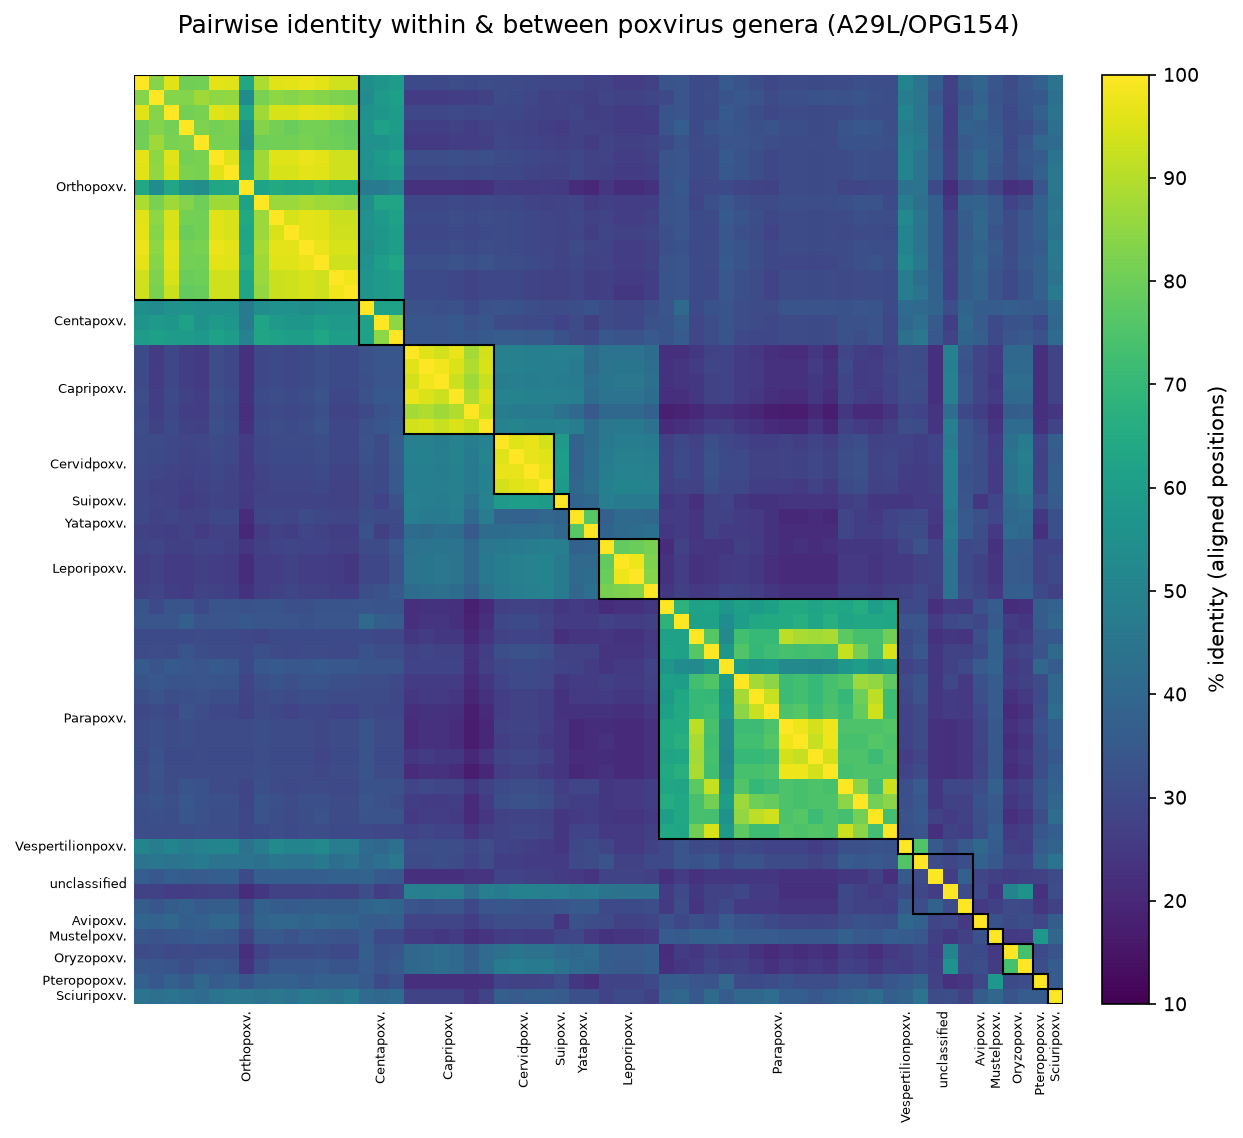

2026-07-23 01:59:35,227 [INFO] DONE — heatmap saved: ['A29L_identity_heatmap.png']


In [8]:
order_index = {g: k for k, g in enumerate(CFG.gorder)}
sort_key = sorted(range(N), key=lambda i: (order_index.get(genera[i], len(CFG.gorder)), genera[i]))
sorted_accs = [accs[i] for i in sort_key]
sorted_genera = [genera[i] for i in sort_key]

df = pd.read_csv(CFG.pairwise_csv, index_col=0)
df_sorted = df.loc[sorted_accs, sorted_accs] * 100

bounds = []
start = 0
for g in pd.Series(sorted_genera).unique():
    n = sorted_genera.count(g)
    bounds.append((start, n, g))
    start += n

fig, ax = plt.subplots(figsize=(10, 9), dpi=150)
im = ax.imshow(df_sorted, cmap="viridis", vmin=10, vmax=100, aspect="equal")

for s, n, g in bounds:
    ax.add_patch(patches.Rectangle((s - 0.5, s - 0.5), n, n, fill=False, ec="black", lw=1.0))

ticks = [s + n / 2 - 0.5 for s, n, g in bounds]
labs = [g.replace("virus", "v.") for s, n, g in bounds]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(labs, rotation=90, ha="center", va="top", fontsize=6)
ax.set_yticklabels(labs, fontsize=6, va="center")
ax.set_title("Pairwise identity within & between poxvirus genera (A29L/OPG154)", pad=20, fontsize=12)
ax.tick_params(length=0)
for sp in ax.spines.values():
    sp.set_visible(False)

cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cb.set_label("% identity (aligned positions)", fontsize=10)
cb.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
written = save_figure(fig, CFG.heatmap_stem)
plt.show()
log.info("DONE — heatmap saved: %s", [p.name for p in written])

## Step 4 — Conservation profiles

Two views of per-column conservation. The **conservation score** for a column is
the count of the most common residue divided by the total number of sequences —
equivalent to identity x occupancy, so a column that is both well-populated and
uniform scores high, while a gappy or variable column scores low. **Occupancy**
(fraction of sequences with a residue) is overlaid.

The first figure plots this across every alignment column. The second maps it
onto the **Monkeypox A29L reference** — located by matching the reference
sequence itself, not an accession — and overlays the known functional domains
(signal peptide, GAG-binding, coiled-coil, leucine zipper) with the
disulfide-linked motif, giving a residue-resolved, biologically annotated view.

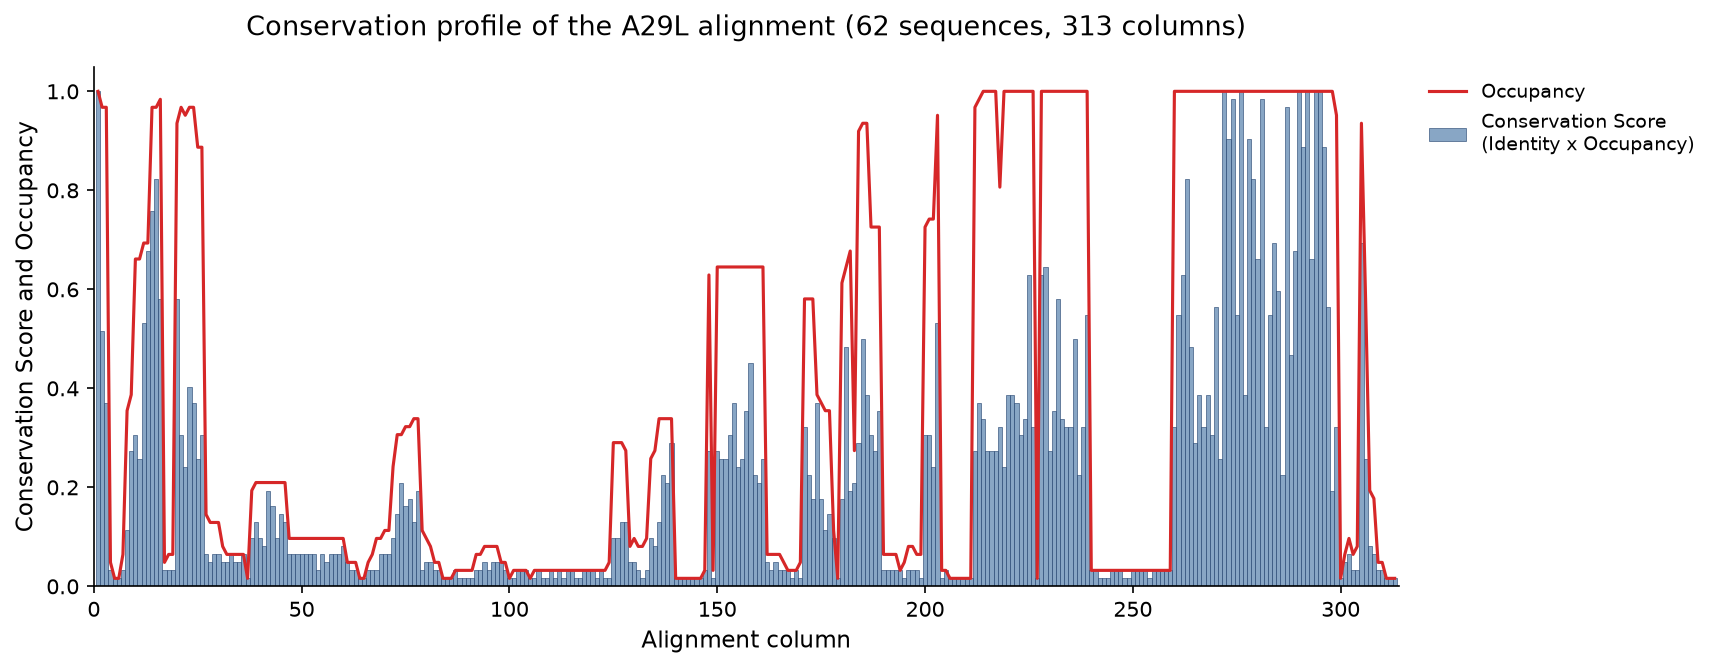

2026-07-23 01:59:40,328 [INFO] DONE — global conservation profile saved: ['A29L_global_conservation_profile.png']


In [9]:
occ = (M != "-").sum(axis=0) / N
ident = np.zeros(L)
for c in range(L):
    col = M[:, c]
    valid = col[col != "-"]
    if len(valid):
        ident[c] = Counter(valid).most_common(1)[0][1] / N

cols = np.arange(1, L + 1)
fig, ax = plt.subplots(figsize=(12, 4.5), dpi=150)
ax.bar(cols, ident, width=1.0, color="#7B9CBF", edgecolor="#1D3E6B", linewidth=0.3,
       alpha=0.9, label="Conservation Score\n(Identity x Occupancy)")
ax.plot(cols, occ, color="#D62728", lw=1.5, label="Occupancy")
ax.set_xlabel("Alignment column", fontsize=11)
ax.set_ylabel("Conservation Score and Occupancy", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, L + 1)
ax.set_title(f"Conservation profile of the A29L alignment ({N} sequences, {L} columns)", pad=15, fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.subplots_adjust(right=0.85)
written = save_figure(fig, CFG.global_profile_stem)
plt.show()
log.info("DONE — global conservation profile saved: %s", [p.name for p in written])

2026-07-23 01:59:40,446 [INFO] Reference located: row 61 (YFT67316.1)


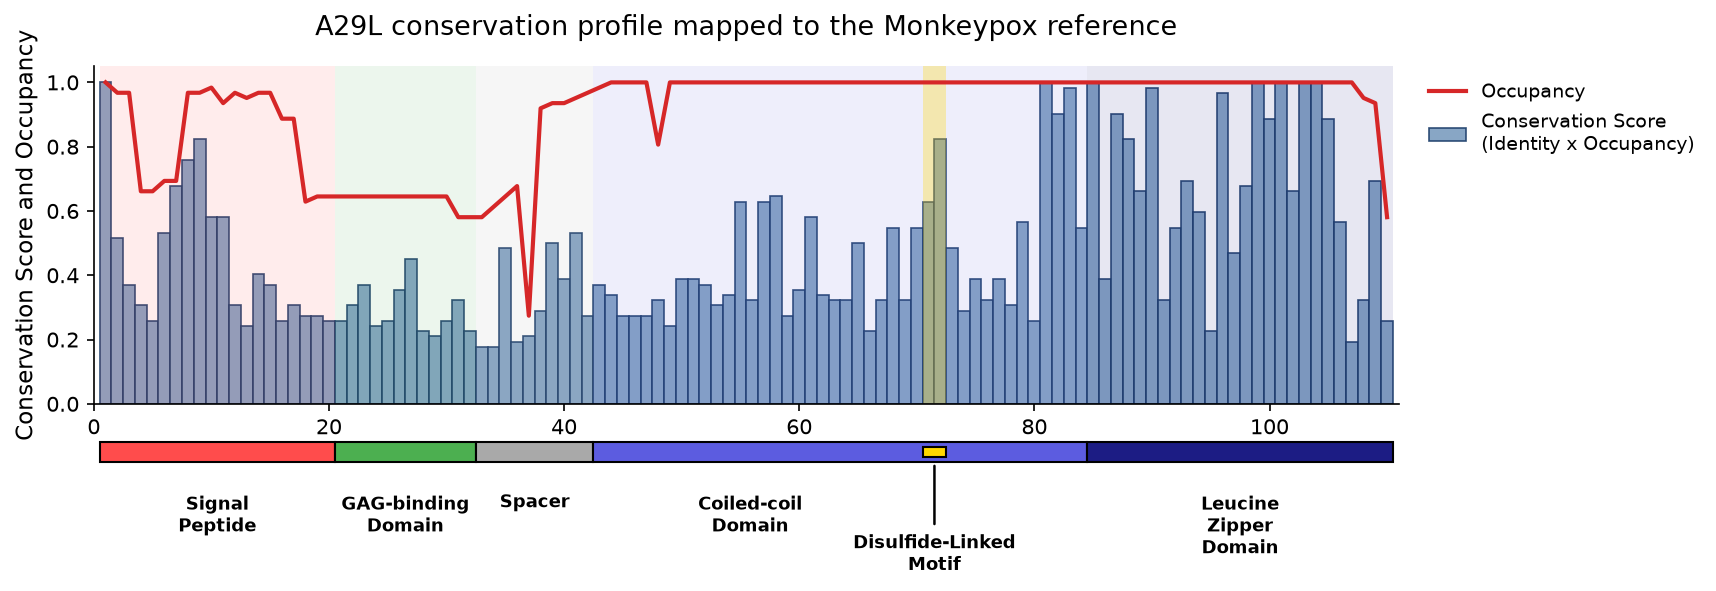

2026-07-23 01:59:44,540 [INFO] DONE — reference-mapped domain profile saved: ['A29L_domain_conservation_profile.png']
2026-07-23 01:59:44,541 [INFO] Phase 7 complete. Outputs in output_phase7


In [10]:
ridx = next(
    (i for i in range(N) if "".join(M[i]).replace("-", "").upper() == CFG.reference_seq.upper()),
    None,
)
if ridx is None:
    raise ValueError(
        "Reference A29L sequence not found in the alignment. "
        "Confirm the reference is present in the 98% set."
    )
log.info("Reference located: row %d (%s)", ridx, accs[ridx])
ref_seq = M[ridx]

rows = []
res_pos = 1
for c in range(L):
    if ref_seq[c] != "-":
        rows.append({
            "ref_res": res_pos, "ref_aa": ref_seq[c], "aln_col": c + 1,
            "occupancy": occ[c], "conservation": ident[c],
        })
        res_pos += 1
refprof = pd.DataFrame(rows)
refprof.to_csv(CFG.reference_mapped_csv, index=False)

fig, ax = plt.subplots(figsize=(12, 4.5), dpi=150)
x = refprof["ref_res"].values
ax.bar(x, refprof["conservation"].values, width=1.0, color="#7B9CBF", edgecolor="#1D3E6B",
       linewidth=0.8, alpha=0.9, label="Conservation Score\n(Identity x Occupancy)")
ax.plot(x, refprof["occupancy"].values, color="#D62728", lw=2.0, label="Occupancy")
ax.set_ylabel("Conservation Score and Occupancy", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, len(x) + 1)
ax.set_title("A29L conservation profile mapped to the Monkeypox reference", pad=15, fontsize=13)

for a, b, color, lab in CFG.domains:
    ax.axvspan(a - 0.5, b + 0.5, color=color, alpha=0.1, lw=0)
ds, de = CFG.disulfide_span
ax.axvspan(ds - 0.5, de + 0.5, color="#FFD700", alpha=0.3, lw=0)

y_box, box_h = -0.18, 0.06
for a, b, color, lab in CFG.domains:
    ax.add_patch(patches.Rectangle((a - 0.5, y_box), b - a + 1, box_h, fc=color, ec="black", lw=1, clip_on=False))
cc_margin = 0.015
ax.add_patch(patches.Rectangle(
    (ds - 0.5, y_box + cc_margin), de - ds + 1, box_h - 2 * cc_margin,
    fc="#FFD700", ec="black", lw=1, clip_on=False, zorder=10,
))

text_y = -0.28
disulfide_mid = (ds + de) / 2
for a, b, color, lab in CFG.domains:
    lx = (a + b) / 2
    if a <= disulfide_mid <= b:
        lx = a + (disulfide_mid - a) * 0.45
    ax.text(lx, text_y, lab.replace(" ", "\n"), ha="center", va="top",
            fontsize=8.5, fontweight="bold", color="black")
ax.annotate("Disulfide-Linked\nMotif", xy=(disulfide_mid, y_box),
            xytext=(disulfide_mid, -0.40),
            ha="center", va="top", fontsize=8.5, fontweight="bold", color="black",
            arrowprops=dict(arrowstyle="-", lw=1.2, color="black"), annotation_clip=False)

ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.subplots_adjust(bottom=0.38, right=0.85)
written = save_figure(fig, CFG.reference_profile_stem)
plt.show()
log.info("DONE — reference-mapped domain profile saved: %s", [p.name for p in written])
log.info("Phase 7 complete. Outputs in %s", CFG.out_dir)